In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt 
import numpy as np
from seaborn import *
from datetime import datetime
import warnings
from sklearn import *
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import *
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error
warnings.simplefilter("ignore")
pd.set_option('display.max_columns', None)

Create DataFrame, Handling Null Values, Filtering Year

In [2]:
# Load CSV files
races_df = pd.read_csv('races.csv')[['raceId', 'year', 'round', 'circuitId', 'name', 'date']]
lap_times_df = pd.read_csv('lap_times.csv')[['raceId', 'driverId', 'lap', 'milliseconds']]
results_df = pd.read_csv('results.csv')[['raceId', 'driverId', 'grid', 'position','positionOrder', 'points', 'laps', 'milliseconds', 'rank']]
drivers_df = pd.read_csv('drivers.csv')[['driverId', 'driverRef']]
pit_stops_df = pd.read_csv('pit_stops.csv')[['raceId', 'driverId', 'lap', 'milliseconds']]

# Merge the DataFrames
merged_df = pd.merge(races_df, lap_times_df, on='raceId')
merged_df = pd.merge(merged_df, results_df, on=['raceId', 'driverId'])
merged_df = pd.merge(merged_df, drivers_df, on='driverId')

# Merge pit_stops_df based on raceId, driverId, and lap
merged_df = pd.merge(merged_df, pit_stops_df, on=['raceId', 'driverId', 'lap'], how='left')

# Replace NaN values with 0
merged_df.fillna(0, inplace=True)

# Rename columns
merged_df.rename(columns={'grid':'starting_pos','positionOrder':'resulted_pos','name': 'race_name','milliseconds_x': 'lap_time_ms', 'laps': 'race_laps','milliseconds_y': 'race_time_ms', 'milliseconds': 'pitstop_ms'}, inplace=True)

# Filter data for the years 2011 to 2023
merged_df = merged_df[(merged_df['year'] >= 2017) & (merged_df['year'] <= 2023)]

# Delete Duplicates
merged_df = merged_df.drop_duplicates()

# Display the resulting DataFrame
merged_df.head()


,raceId,year,round,circuitId,race_name,date,driverId,lap,lap_time_ms,starting_pos,position,resulted_pos,points,race_laps,race_time_ms,rank,driverRef,pitstop_ms
10506,969,2017,1,1,Australian Grand Prix,2017-03-26,1,1,94404,1,2,2,18.0,57,5061647,6,hamilton,0.0
10507,969,2017,1,1,Australian Grand Prix,2017-03-26,1,2,89638,1,2,2,18.0,57,5061647,6,hamilton,0.0
10508,969,2017,1,1,Australian Grand Prix,2017-03-26,1,3,89119,1,2,2,18.0,57,5061647,6,hamilton,0.0
10509,969,2017,1,1,Australian Grand Prix,2017-03-26,1,4,89044,1,2,2,18.0,57,5061647,6,hamilton,0.0
10510,969,2017,1,1,Australian Grand Prix,2017-03-26,1,5,88786,1,2,2,18.0,57,5061647,6,hamilton,0.0


Show Rows Where Races Had Pitstops

In [3]:
# Filter rows where pitstops are not equal to 0
filtered_df = merged_df[merged_df['pitstop_ms'] != 0]
# Display the resulting DataFrame
filtered_df.head()

,raceId,year,round,circuitId,race_name,date,driverId,lap,lap_time_ms,starting_pos,position,resulted_pos,points,race_laps,race_time_ms,rank,driverRef,pitstop_ms
10522,969,2017,1,1,Australian Grand Prix,2017-03-26,1,17,106345,1,2,2,18.0,57,5061647,6,hamilton,21709.0
10566,970,2017,2,17,Chinese Grand Prix,2017-04-09,1,4,130924,1,1,1,25.0,56,5856158,1,hamilton,22999.0
10567,970,2017,2,17,Chinese Grand Prix,2017-04-09,1,5,180642,1,1,1,25.0,56,5856158,1,hamilton,17616.0
10568,970,2017,2,17,Chinese Grand Prix,2017-04-09,1,6,167366,1,1,1,25.0,56,5856158,1,hamilton,17737.0
10598,970,2017,2,17,Chinese Grand Prix,2017-04-09,1,36,101641,1,1,1,25.0,56,5856158,1,hamilton,22668.0


Show 2023 Highest Scoring Drivers

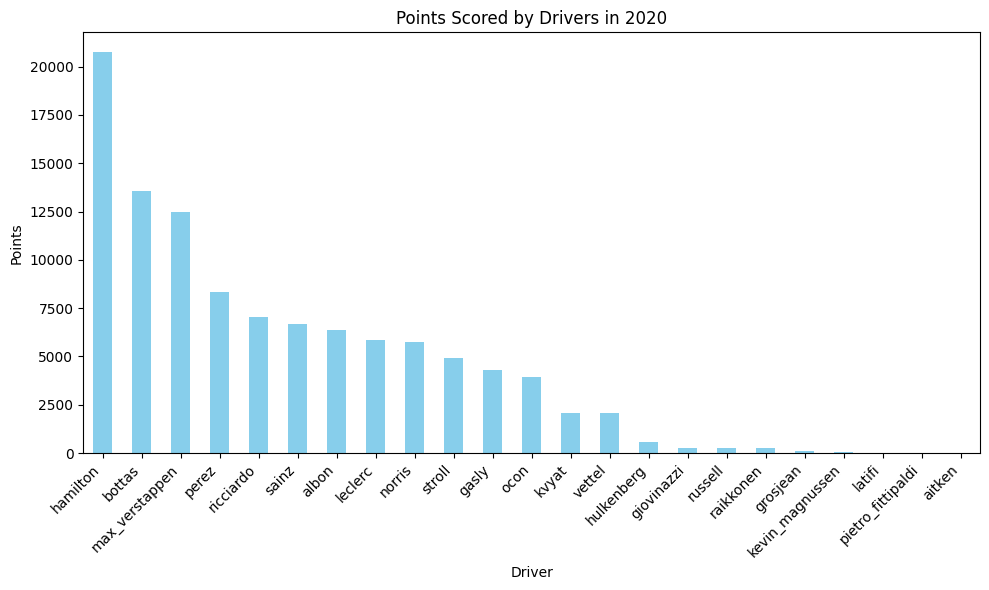

In [4]:
import matplotlib.pyplot as plt

# Filter data for the year 2023
merged_df_2023 = merged_df[merged_df['year'] == 2023]

# Group by driverRef and sum the points
points_by_driver = merged_df_2023.groupby('driverRef')['points'].sum().sort_values(ascending=False)

# Plot the bar graph
plt.figure(figsize=(10, 6))
points_by_driver.plot(kind='bar', color='skyblue')
plt.title('Points Scored by Drivers in 2023')
plt.xlabel('Driver')
plt.ylabel('Points')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()




Show 2023 Most Pitstop Times MS

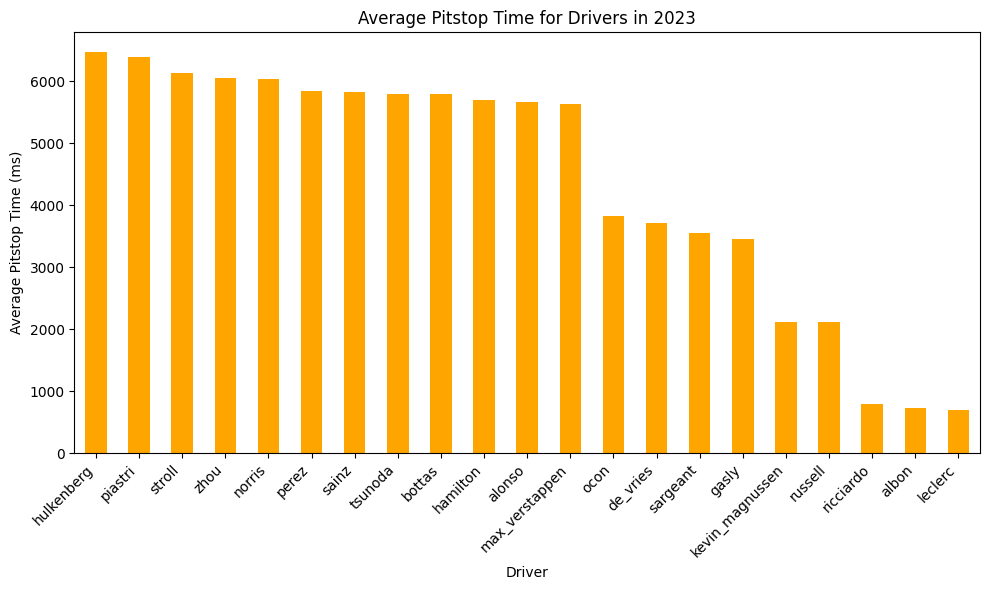

In [18]:
# Filter data for the year 2023
merged_df_2023 = merged_df[merged_df['year'] == 2023]

# Group by driverRef and calculate the average pitstop time (in milliseconds)
pitstop_time_by_driver = merged_df_2023.groupby('driverRef')['pitstop_ms'].mean().sort_values(ascending=False)

# Plot the bar graph
plt.figure(figsize=(10, 6))
pitstop_time_by_driver.plot(kind='bar', color='orange')
plt.title('Average Pitstop Time for Drivers in 2023')
plt.xlabel('Driver')
plt.ylabel('Average Pitstop Time (ms)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


HeatMap

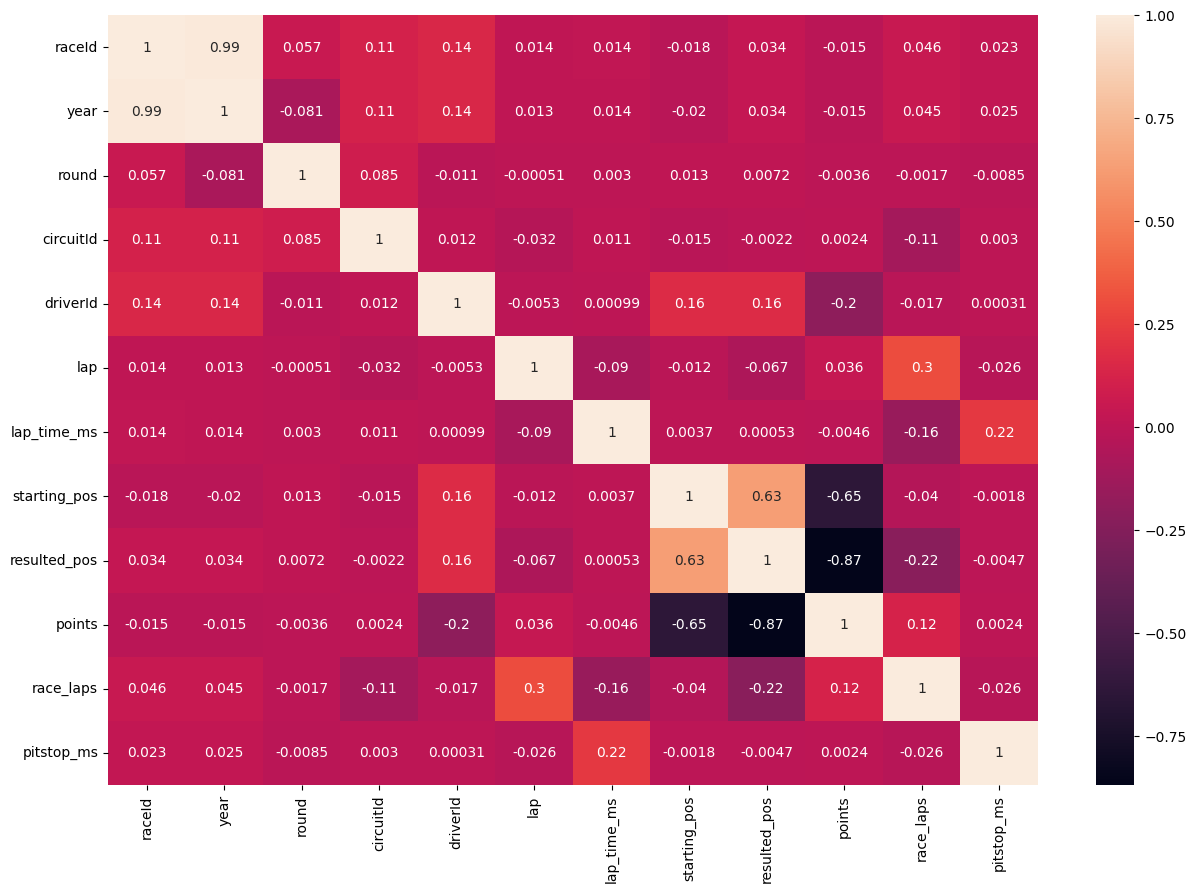

In [6]:
# Make list for numerical columns
numeric_columns = merged_df.select_dtypes(include=['float64', 'int64'])

# Plot HeatMap
plt.figure(figsize=(15, 10))
sns.heatmap(numeric_columns.corr(), annot=True)
plt.show()



KDE

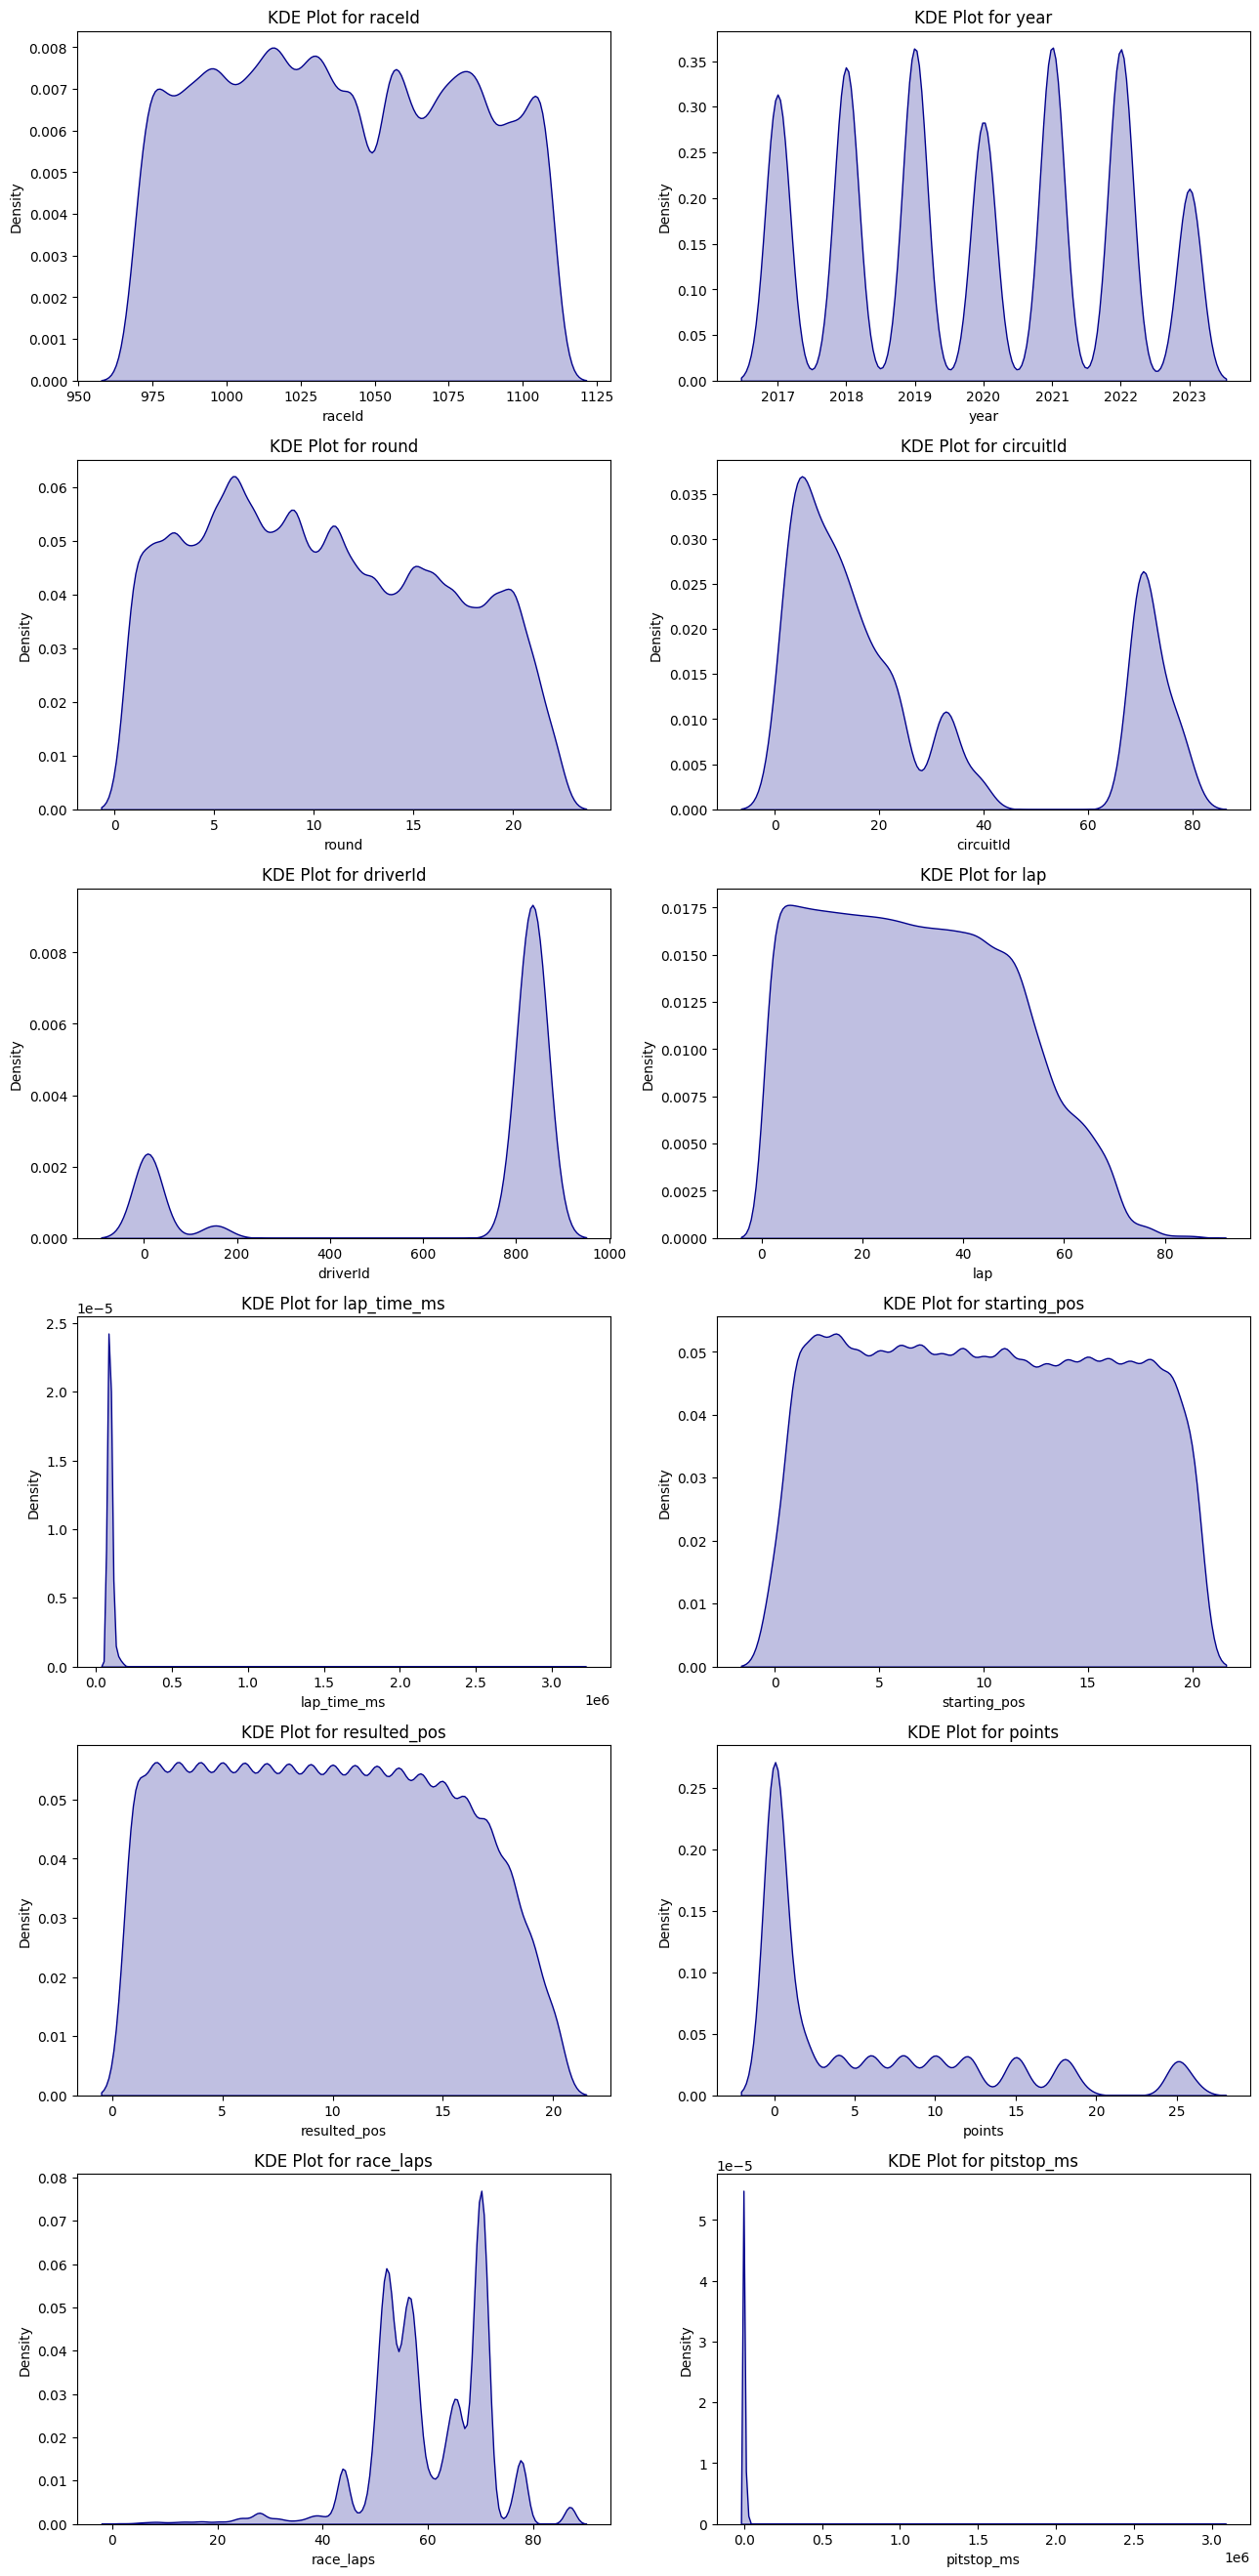

In [7]:
# empty list to store numerical column names
num = []

# Iterate through columns
for column in merged_df.columns:
    # Check if the data type is either int or float
    if merged_df[column].dtype in ['int64', 'float64']:
        # Append the column name to the list
        num.append(column)

# Create a subplot grid based on the number of numerical columns
plt.figure(figsize=(13, 48)) 
for i, column in enumerate(num, start=1):
    plt.subplot(11, 2, i)  # Sizing
    sns.kdeplot(merged_df[column], shade=True, color='darkblue') 
    plt.title(f'KDE Plot for {column}')  # Add title 

plt.tight_layout()  # Adjust layout
plt.show()  # plot


In [8]:
numeric_columns.skew()

raceId           0.056964
year             0.021468
round            0.179735
circuitId        0.880114
driverId        -1.393864
lap              0.248333
lap_time_ms     25.688444
starting_pos     0.030270
resulted_pos     0.079512
points           1.242553
race_laps       -0.844107
pitstop_ms      28.371539
dtype: float64

Machine Learning!!!

In [9]:
x = merged_df[['starting_pos', 'resulted_pos', 'points', 'race_laps', 'pitstop_ms']]
y = merged_df['lap_time_ms']

# Split the data into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# Create and train a Linear Regression model
model = LinearRegression()
model.fit(x_train, y_train)

LinearRegression()

In [10]:
# Create and train a Linear Regression model
lr = LinearRegression()
lr.fit(x_train, y_train)

# Create and train a Decision Tree Regressor model
dtc = DecisionTreeRegressor()
dtc.fit(x_train, y_train)

# Create and train a Random Forest Regressor model
rfc = RandomForestRegressor()
rfc.fit(x_train, y_train)

# Create and train a k-Nearest Neighbors Regressor model
knn = KNeighborsRegressor()
knn.fit(x_train, y_train)

# Create and train a Support Vector Regressor model
svr = SVR()
svr.fit(x_train, y_train)

# Create and train a Gradient Boosting Regressor model
gbr = GradientBoostingRegressor()
gbr.fit(x_train, y_train)

# Make predictions and evaluate each model
models = [lr, dtc, rfc, knn, svr, gbr]
for model in models:
    predictions = model.predict(x_test)
    mse = mean_squared_error(y_test, predictions)
    print(f"{model.__class__.__name__} - Mean Squared Error: {mse}")

LinearRegression - Mean Squared Error: 4025572036.382273
DecisionTreeRegressor - Mean Squared Error: 3524417030.832227
RandomForestRegressor - Mean Squared Error: 3440109474.1619244
KNeighborsRegressor - Mean Squared Error: 4306721502.6871395
SVR - Mean Squared Error: 4166470222.434125
GradientBoostingRegressor - Mean Squared Error: 3466159041.944566


In [11]:
from sklearn.preprocessing import MinMaxScaler

# Create and apply MinMaxScaler
scaler = MinMaxScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

# Create and train a Linear Regression model
lr = LinearRegression()
lr.fit(x_train_scaled, y_train)

# Create and train a Decision Tree Regressor model
dtc = DecisionTreeRegressor()
dtc.fit(x_train_scaled, y_train)

# Create and train a Random Forest Regressor model
rfc = RandomForestRegressor()
rfc.fit(x_train_scaled, y_train)

# Create and train a k-Nearest Neighbors Regressor model
knn = KNeighborsRegressor()
knn.fit(x_train_scaled, y_train)

# Create and train a Support Vector Regressor model
svr = SVR()
svr.fit(x_train_scaled, y_train)

# Create and train a Gradient Boosting Regressor model
gbr = GradientBoostingRegressor()
gbr.fit(x_train_scaled, y_train)

# Make predictions and evaluate each model
models = [lr, dtc, rfc, knn, svr, gbr]
for model in models:
    predictions = model.predict(x_test_scaled)
    mse = mean_squared_error(y_test, predictions)
    print(f"{model.__class__.__name__} - Mean Squared Error: {mse}")


LinearRegression - Mean Squared Error: 4025572036.382417
DecisionTreeRegressor - Mean Squared Error: 3524766461.49204
RandomForestRegressor - Mean Squared Error: 3461230182.327663
KNeighborsRegressor - Mean Squared Error: 4308923741.047964
SVR - Mean Squared Error: 4135977440.3448653
GradientBoostingRegressor - Mean Squared Error: 3470536186.6514707


In [12]:
from sklearn.preprocessing import StandardScaler

# Create and apply StandardScaler
scaler_std = StandardScaler()
x_train_std = scaler_std.fit_transform(x_train)
x_test_std = scaler_std.transform(x_test)

# Create and train a Linear Regression model with standardized data
lr_std = LinearRegression()
lr_std.fit(x_train_std, y_train)

# Create and train a Decision Tree Regressor model with standardized data
dtc_std = DecisionTreeRegressor()
dtc_std.fit(x_train_std, y_train)

# Create and train a Random Forest Regressor model with standardized data
rfc_std = RandomForestRegressor()
rfc_std.fit(x_train_std, y_train)

# Create and train a k-Nearest Neighbors Regressor model with standardized data
knn_std = KNeighborsRegressor()
knn_std.fit(x_train_std, y_train)

# Create and train a Support Vector Regressor model with standardized data
svr_std = SVR()
svr_std.fit(x_train_std, y_train)

# Create and train a Gradient Boosting Regressor model with standardized data
gbr_std = GradientBoostingRegressor()
gbr_std.fit(x_train_std, y_train)

# Make predictions and evaluate each model with standardized data
models_std = [lr_std, dtc_std, rfc_std, knn_std, svr_std, gbr_std]
for model in models_std:
    predictions_std = model.predict(x_test_std)
    mse_std = mean_squared_error(y_test, predictions_std)
    print(f"{model.__class__.__name__} with StandardScaler - Mean Squared Error: {mse_std}")


LinearRegression with StandardScaler - Mean Squared Error: 4025572036.3824177
DecisionTreeRegressor with StandardScaler - Mean Squared Error: 3413379851.6269255
RandomForestRegressor with StandardScaler - Mean Squared Error: 3438604978.683291
KNeighborsRegressor with StandardScaler - Mean Squared Error: 4473619938.107888
SVR with StandardScaler - Mean Squared Error: 4095331931.001636
GradientBoostingRegressor with StandardScaler - Mean Squared Error: 3451009119.7814255


In [13]:
from sklearn.preprocessing import RobustScaler

# Create and apply RobustScaler
scaler_robust = RobustScaler()
x_train_robust = scaler_robust.fit_transform(x_train)
x_test_robust = scaler_robust.transform(x_test)

# Create and train a Linear Regression model with robustly scaled data
lr_robust = LinearRegression()
lr_robust.fit(x_train_robust, y_train)

# Create and train a Decision Tree Regressor model with robustly scaled data
dtc_robust = DecisionTreeRegressor()
dtc_robust.fit(x_train_robust, y_train)

# Create and train a Random Forest Regressor model with robustly scaled data
rfc_robust = RandomForestRegressor()
rfc_robust.fit(x_train_robust, y_train)

# Create and train a k-Nearest Neighbors Regressor model with robustly scaled data
knn_robust = KNeighborsRegressor()
knn_robust.fit(x_train_robust, y_train)

# Create and train a Support Vector Regressor model with robustly scaled data
svr_robust = SVR()
svr_robust.fit(x_train_robust, y_train)

# Create and train a Gradient Boosting Regressor model with robustly scaled data
gbr_robust = GradientBoostingRegressor()
gbr_robust.fit(x_train_robust, y_train)

# Make predictions and evaluate each model with robustly scaled data
models_robust = [lr_robust, dtc_robust, rfc_robust, knn_robust, svr_robust, gbr_robust]
for model in models_robust:
    predictions_robust = model.predict(x_test_robust)
    mse_robust = mean_squared_error(y_test, predictions_robust)
    print(f"{model.__class__.__name__} with RobustScaler - Mean Squared Error: {mse_robust}")


LinearRegression with RobustScaler - Mean Squared Error: 4025572036.381028
DecisionTreeRegressor with RobustScaler - Mean Squared Error: 3524207210.4174976
RandomForestRegressor with RobustScaler - Mean Squared Error: 3460376645.5074544
KNeighborsRegressor with RobustScaler - Mean Squared Error: 4393178950.982305
SVR with RobustScaler - Mean Squared Error: 4166470312.0224295
GradientBoostingRegressor with RobustScaler - Mean Squared Error: 3448955566.0144053


In [15]:
from sklearn.model_selection import cross_val_score, KFold
from sklearn.preprocessing import RobustScaler, StandardScaler, MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.ensemble import GradientBoostingRegressor

# Define the models
models = [
    LinearRegression(),
    DecisionTreeRegressor(),
    RandomForestRegressor(),
    KNeighborsRegressor(),
    SVR(),
    GradientBoostingRegressor()
]

# Define the scalers
scalers = [RobustScaler(), StandardScaler(), MinMaxScaler()]

# Loop through models
for model in models:
    print(f"Model: {model.__class__.__name__}")
    
    # Loop through scalers
    for scaler in scalers:
        # Scale the features
        x_scaled = scaler.fit_transform(x)
        
        # Set up cross-validation with k folds
        k_folds = 5  
        cv = KFold(n_splits=k_folds, shuffle=True, random_state=42)
        
        # Perform cross-validation and calculate mean squared error
        mse_scores = cross_val_score(model, x_scaled, y, scoring='neg_mean_squared_error', cv=cv)
        mse_mean = -mse_scores.mean()
        
        # Print results
        print(f"  Scaler: {scaler.__class__.__name__} - Mean Squared Error: {mse_mean}")


Model: LinearRegression
  Scaler: RobustScaler - Mean Squared Error: 4746642005.724653
  Scaler: StandardScaler - Mean Squared Error: 4746642005.723783
  Scaler: MinMaxScaler - Mean Squared Error: 4746642005.7237835
Model: DecisionTreeRegressor
  Scaler: RobustScaler - Mean Squared Error: 4196389937.530324
  Scaler: StandardScaler - Mean Squared Error: 4268402479.7538805
  Scaler: MinMaxScaler - Mean Squared Error: 4185228743.9612336
Model: RandomForestRegressor
  Scaler: RobustScaler - Mean Squared Error: 4018503326.670265
  Scaler: StandardScaler - Mean Squared Error: 4010150455.6757812
  Scaler: MinMaxScaler - Mean Squared Error: 4002419153.78831
Model: KNeighborsRegressor
  Scaler: RobustScaler - Mean Squared Error: 5925582900.470606
  Scaler: StandardScaler - Mean Squared Error: 6060703503.51938
  Scaler: MinMaxScaler - Mean Squared Error: 6360562729.201612
Model: SVR
  Scaler: RobustScaler - Mean Squared Error: 5128041856.892235
  Scaler: StandardScaler - Mean Squared Error: 5055

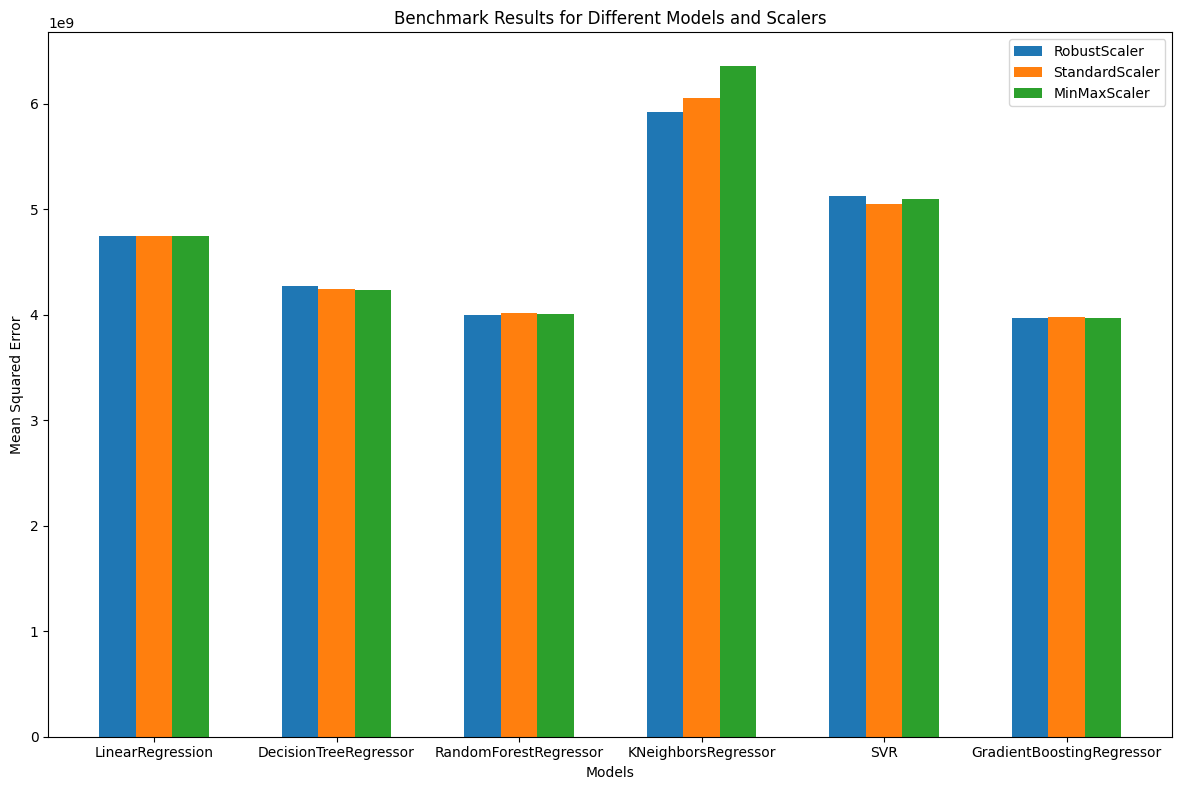

In [16]:
import matplotlib.pyplot as plt
import numpy as np

# Store results in a dictionary
results = {}

# Loop through models
for model in models:
    model_name = model.__class__.__name__
    
    # Loop through scalers
    for scaler in scalers:
        scaler_name = scaler.__class__.__name__
        
        # Scale the features
        x_scaled = scaler.fit_transform(x)
        
        # Set up cross-validation with k folds
        k_folds = 5  
        cv = KFold(n_splits=k_folds, shuffle=True, random_state=42)
        
        # Perform cross-validation and calculate mean squared error
        mse_scores = cross_val_score(model, x_scaled, y, scoring='neg_mean_squared_error', cv=cv)
        mse_mean = -mse_scores.mean()
        
        # Store the results in the dictionary
        results[(model_name, scaler_name)] = mse_mean

# Extract data for plotting
model_names = [model.__class__.__name__ for model in models]
scaler_names = [scaler.__class__.__name__ for scaler in scalers]
bar_width = 0.2
bar_positions = np.arange(len(model_names))

# Plot the bar chart
plt.figure(figsize=(12, 8))

for i, scaler_name in enumerate(scaler_names):
    mse_values = [results[(model_name, scaler_name)] for model_name in model_names]
    plt.bar(bar_positions + i * bar_width, mse_values, bar_width, label=scaler_name)

plt.xlabel('Models')
plt.ylabel('Mean Squared Error')
plt.title('Benchmark Results for Different Models and Scalers')
plt.xticks(bar_positions + bar_width * (len(scalers) - 1) / 2, model_names)
plt.legend()

plt.tight_layout()
plt.show()


In [17]:
from sklearn.metrics import r2_score

# Define the models
models = [
    LinearRegression(),
    DecisionTreeRegressor(),
    RandomForestRegressor(),
    KNeighborsRegressor(),
    SVR(),
    GradientBoostingRegressor()
]

# Loop through models
for model in models:
    model_name = model.__class__.__name__
    
    # Scale the features 
    scaler = StandardScaler()
    x_train_scaled = scaler.fit_transform(x_train)
    x_test_scaled = scaler.transform(x_test)
    
    # Train the model
    model.fit(x_train_scaled, y_train)
    
    # Make predictions on the test set
    predictions = model.predict(x_test_scaled)
    
    # Calculate R-squared
    r_squared = r2_score(y_test, predictions)
    
    # Print the R-squared
    print(f'R-squared for {model_name}: {r_squared}')

R-squared for LinearRegression: 0.02865937959395748
R-squared for DecisionTreeRegressor: 0.17639832860887128
R-squared for RandomForestRegressor: 0.16736995517459574
R-squared for KNeighborsRegressor: -0.07945124987691488
R-squared for SVR: 0.011826835372544253
R-squared for GradientBoostingRegressor: 0.16839012758713168
